# Hola &#x1F600;,

Soy **Hesus Garcia** – **"Soy el único Hesus que conoces (y probablemente conocerás) 🌟"** – Sí, como "Jesús", pero con una H que me hace único. Puede sonar raro, pero créeme, ¡no lo olvidarás! Como tu revisor en Triple-Ten, estoy aquí para guiarte y ayudarte a mejorar tu código. Si algo necesita un ajuste, no hay de qué preocuparse; ¡aquí estoy para hacer que tu trabajo brille con todo su potencial! ✨

Cada vez que encuentre un detalle importante en tu código, te lo señalaré para que puedas corregirlo y así te prepares para un ambiente de trabajo real, donde el líder de tu equipo actuaría de manera similar. Si en algún momento no logras solucionar el problema, te daré más detalles para ayudarte en nuestra próxima oportunidad de revisión.

Es importante que cuando encuentres un comentario, **no los muevas, no los modifiques, ni los borres**.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> - ¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis de datos o al proyecto. Continúa aplicando estas buenas prácticas en futuras secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Este código está correcto, pero se puede optimizar. Considera implementar mejoras para que sea más eficiente y fácil de leer. Esto fortalecerá la calidad de tu proyecto.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error en el código que es necesario corregir para aprobar esta sección. Por favor, revisa y corrige este punto, ya que es fundamental para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto.
- **Áreas de mejora:** Sugerencias sobre aspectos donde puedes mejorar.
- **Temas adicionales para investigar:** Ideas de temas opcionales que puedes explorar por tu cuenta para desarrollar aún más tus habilidades.

Estos temas adicionales no son obligatorios en esta etapa, pero pueden serte útiles para profundizar en el futuro.

---


Esta estructura en viñetas facilita la lectura y comprensión de cada parte del comentario final.

También puedes responderme de la siguiente manera si tienes alguna duda o quieres aclarar algo específico:


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>


**¡Empecemos!** &#x1F680;


# Proyecto Final - Predicción de Cancelación de Clientes en la operadora Interconnect

### 1. Introducción (Contexto y Objetivo del proyecto)
El operador de telecomunicacciones Interconnect desea poder pronosticar su tasa tasa de cancelación de clientes.
SI se descubre que un usuario planea irse, se le ofrecerán códigos promocionales y planes especiales para mejorar su retención.  

El equipo de marketing ha recopilado datos personales, información de contratos y servicios de los clientes.  

**Servicios principales:**
- Telefonía fija (líneas múltiples).
- Internet: DSL o Fibra Óptica.
- Servicios adicionales: seguridad en línea, soporte técnico, backup en la nube, streaming TV y películas.

**Contratos:**
- Pago mensual o contratos de 1–2 años.
- Diferentes métodos de pago, con facturación electrónica.

### Objetivo del proyecto
Construir un modelo de Machine Learning capaz de predecir churn (cancelación) de clientes.  
Esto permitirá que Interconnect diseñe campañas de retención más efectivas.



<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Contexto y objetivo muy claros; la descripción de servicios y contratos enmarca adecuadamente el problema de churn. Excelente punto de partida. </div>


### 2. Cargar librerías y Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, classification_report, recall_score, f1_score
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
contract = pd.read_csv('/datasets/final_provider/contract.csv')
personal = pd.read_csv('/datasets/final_provider/personal.csv')
internet = pd.read_csv('/datasets/final_provider/internet.csv')
phone = pd.read_csv('/datasets/final_provider/phone.csv')

df = (
    contract
    .merge(personal, on="customerID", how="left")
    .merge(internet, on="customerID", how="left")
    .merge(phone, on="customerID", how="left")
)

df.head()


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No


Descripción: Al unir los datasets con customerID integra toda la información en un solo dataframe, asegurando consistencia y facilitando el análisis completo de los clientes.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Muy bien estructurada la carga de librerías y la integración de los datasets en un único dataframe; es un paso sólido para asegurar consistencia en el análisis posterior. </div>


 ### 3 Exploración de Datos (EDA)
 


#### 3.1 Inspección de Datos

        3.1.1. Tipos de variables (df.info)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   5517 non-null   object 
 13  OnlineSecurity    5517 non-null   object 
 14  OnlineBackup      5517 non-null   object 
 15  DeviceProtection  5517 non-null   object 
 16  TechSupport       5517 non-null   object 


**Descripción:** 
El dataset tiene 7.043 clientes y 20 columnas; la mayoría son categóricas, además hay dos numéricas llamadas MonthlyCharges y TotalCharges, una entera que es SeniorCitizen y una de fecha que es EndDate. BeginDate está como texto, por lo tanto hay que convertirla a tipo fecha. En servicios de internet hay siete columnas y, junto con MultipleLines, presentan valores nulos porque algunas personas no contrataron esos servicios. En TotalCharges existen 11 nulos reales, es decir, son errores que debemos corregir. EndDate tiene 1.869 valores registrados

        3.2.1. Revisar valores nulos (df.isnull().sum())

In [4]:
df.isnull().sum()

customerID             0
BeginDate              0
EndDate                0
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
dtype: int64

**Descripción:** 
Al analizar los valores nulos del dataset combinado se observa que la mayoría no corresponden a errores, sino a situaciones propias del negocio. Por ejemplo, en EndDate hay 5174 valores nulos, que representan a los clientes que siguen activos; en las columnas de Internet tiene 1526 nulos, debido a los vacíos se deben a que ciertos usuarios no contrataron ese servicio, y en MultipleLines tiene 682 valores nulos, esto ocurre lo mismo con quienes no tienen telefonía fija. En contraste, en TotalCharges se identifican 11 nulos reales, que sí reflejan registros incompletos y deberán tratarse en la etapa de preparación de datos.

        3.3.3. Revisar valores duplicados (df.duplicated().sum())


In [5]:
#Valores Duplicados 
print("Número de duplicados del dataset:", df.duplicated().sum())
df = df.drop_duplicates()

Número de duplicados del dataset: 0


**Descripción:** 
El dataset no presenta registros duplicados en sus observaciones, lo que garantiza que cada cliente cuenta con un identificador único y que la información almacenada en esta tabla no se encuentra repetida.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - El análisis exploratorio inicial está muy bien planteado; identificaste correctamente tipos de variables, valores nulos y duplicados, lo que muestra una comprensión sólida de la calidad de los datos. </div>


#### 3.2. Análisis descriptivo 

        3.2.1 Estadística descriptiva (df.describe)

In [6]:
# Resumen estadístico de las columnas númericas
df.describe()

,MonthlyCharges,SeniorCitizen
count,7043.000000,7043.000000
mean,64.761692,0.162147
std,30.090047,0.368612
min,18.250000,0.000000
25%,35.500000,0.000000
50%,70.350000,0.000000
75%,89.850000,0.000000
max,118.750000,1.000000


**Descripción:** 

-**MonthlyCharges:** Hay 7 043 registros. La media es 64.76 y la mediana es 70.35, es decir la distribución tira un poco hacia valores bajos porque la mediana supera a la media. El 25 % paga hasta 35.50, el 50 % paga 70.35 y el 75 % paga 89.85. El mínimo es 18.25 y el máximo es 118.75. La dispersión es alta, por lo tanto existen planes muy económicos y planes premium.
    
-**TotalCharges:** Hay 7 032 registros y faltan 11, es decir existen 11 nulos que debemos corregir. La media es 2 283.30 y la mediana es 1 397.48, por lo tanto la distribución está cargada a la derecha con clientes que han pagado muchísimo a lo largo del tiempo. El 25 % acumula hasta 401.45 y el 75 % hasta 3 794.74. El rango va de 18.80 hasta 8 684.80. La variabilidad es muy alta, además TotalCharges refleja tiempo en el servicio y tipo de plan.
    
-**SeniorCitizen:** Hay 7 043 registros. La media es 0.162, es decir alrededor del 16.2 % de la clientela es adulta mayor y el 83.8 % no lo es. Los cuartiles quedan en cero, por lo tanto la mayoría no pertenece a este grupo..


        3.2.2 Histogramas de variables númericas

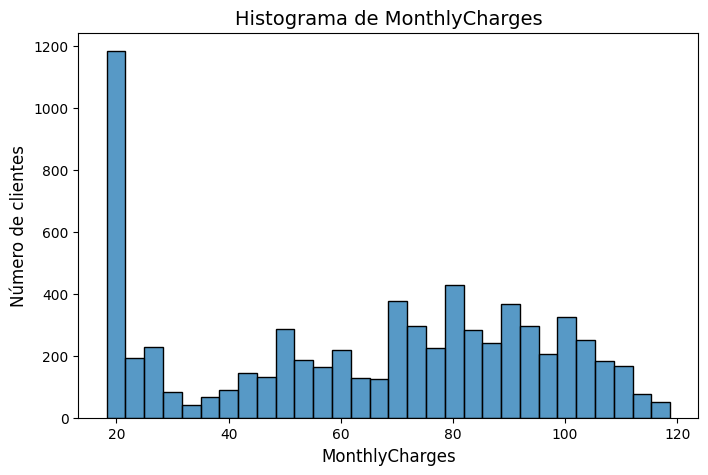

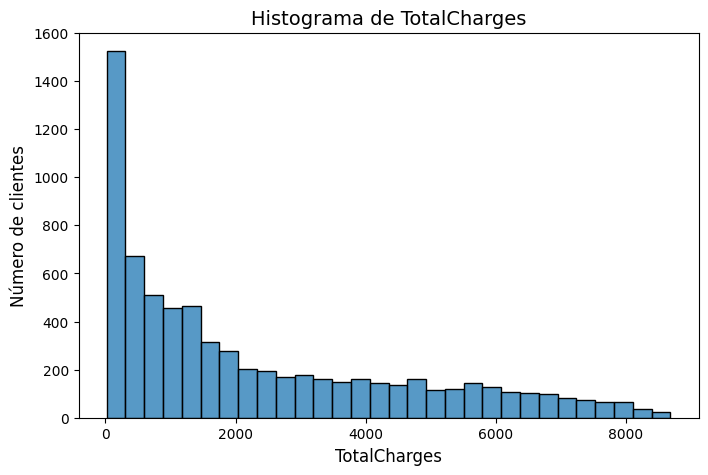

In [7]:
# Convertir TotalCharges a numérico (los valores no numéricos se convierten a NaN)
contract['TotalCharges'] = pd.to_numeric(contract['TotalCharges'], errors='coerce')

# Calcular la mediana de TotalCharges sin considerar los NaN
median_totalcharges = contract['TotalCharges'].median(skipna=True)

# Rellenar los valores NaN con la mediana
contract['TotalCharges'] = contract['TotalCharges'].fillna(median_totalcharges)

# Lista de variables numéricas que quieres analizar
num_cols = ['MonthlyCharges', 'TotalCharges']  

# Histograma de las variables númericas
for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(data=contract, x=col, bins=30, kde=False, edgecolor="black")
    plt.title(f"Histograma de {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Número de clientes", fontsize=12)
    plt.show()

**Descipción:** 

-En el histograma de MonthlyCharges hay un grupo grande pagando planes baratos cerca de 20 y luego una dispersión amplia desde 35 hasta 110, por lo tanto existen muchos tipos de planes y conviene observar adecuadamente quienes pagan más de 90 porque el precio puede empujarlos a cancelar el servicio.

-En el Histograma de TotalCharges está muy cargado a la izquierda, es decir la mayoría ha pagado poco en total y eso indica clientes recientes, mientras que pocos acumulan montos altos y esos suelen ser clientes leales. Juntando ambas pistas, si alguien paga mucho al mes y aún tiene total pagado bajo entonces es nuevo y caro y por ende es un candidato de riesgo; en cambio, quien acumula mucho total normalmente lleva tiempo y muestra fidelidad.

        3.2.3 Boxplots de variables númericas

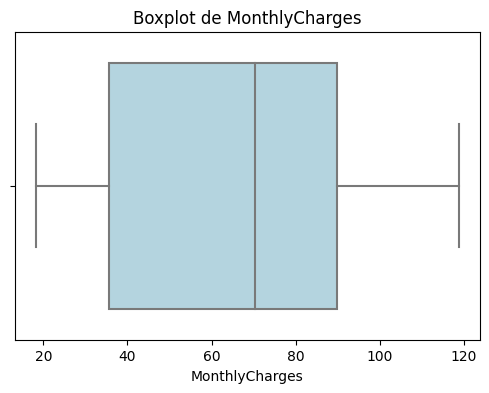

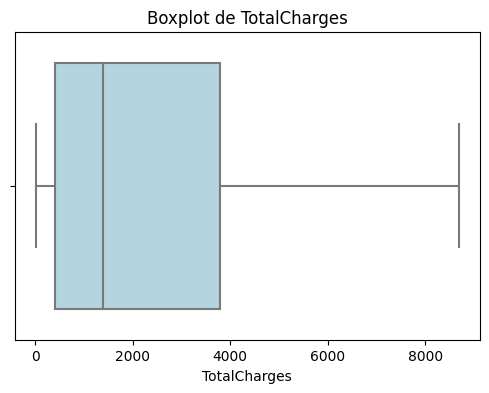

In [8]:
num_cols = ['MonthlyCharges', 'TotalCharges']  
# Boxplots para detectar valores atípicos en variables numéricas originales
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=contract[col], color="lightblue")
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()


**Descipción:** 

**-Boxplot de MonthlyCharges (cargos mensuales):**
La mayoría de los clientes pagan entre aproximadamente 40 y 80 dólares mensuales, con una mediana cercana a los 70 dólares. Se observan valores mínimos alrededor de 20 dólares (planes básicos) y máximos que llegan a los 120 dólares (planes más completos con varios servicios). La distribución se ve bastante simétrica, con pocos valores extremos.

**-Boxplot de TotalCharges (cargos totales):**
El gasto acumulado de los clientes muestra una mayor dispersión. La mediana está cerca de los 2,000 dólares, pero hay clientes con montos muy bajos (nuevos en la compañía) y otros con valores muy altos, que superan los 8,000 dólares. Esto refleja que hay clientes con larga permanencia o muchos servicios contratados. Aquí sí aparecen más valores atípicos, pero se entienden como parte del negocio (clientes con mucha antigüedad).

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - El análisis descriptivo está bien fundamentado; la interpretación de estadísticas, histogramas y boxplots refleja una lectura clara de la variabilidad en los planes y la permanencia de los clientes. </div>


#### 3.4. Análisis categórico

        3.4.1. Conteo de Categorias (value_counts)  

In [9]:
# Función para mostrar conteos
def mostrar_conteos(df, columnas):
    for col in columnas:
        print(f"\nColumna: {col}")
        print(df[col].value_counts())

cols_contract = ["Type", "PaperlessBilling", "PaymentMethod"]
cols_personal = ["gender", "SeniorCitizen", "Partner", "Dependents"]
cols_internet = ["InternetService", "OnlineSecurity", "OnlineBackup",
                 "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
cols_phone = ["MultipleLines"]

print("------ CONTRACT -------")
mostrar_conteos(contract, cols_contract)

print("------ PERSONAL -------")
mostrar_conteos(personal, cols_personal)

print("------ INTERNET -------")
mostrar_conteos(internet, cols_internet)

print("------- PHONE ---------")
mostrar_conteos(phone, cols_phone)



------ CONTRACT -------

Columna: Type
Month-to-month    3875
Two year          1695
One year          1473
Name: Type, dtype: int64

Columna: PaperlessBilling
Yes    4171
No     2872
Name: PaperlessBilling, dtype: int64

Columna: PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: PaymentMethod, dtype: int64
------ PERSONAL -------

Columna: gender
Male      3555
Female    3488
Name: gender, dtype: int64

Columna: SeniorCitizen
0    5901
1    1142
Name: SeniorCitizen, dtype: int64

Columna: Partner
No     3641
Yes    3402
Name: Partner, dtype: int64

Columna: Dependents
No     4933
Yes    2110
Name: Dependents, dtype: int64
------ INTERNET -------

Columna: InternetService
Fiber optic    3096
DSL            2421
Name: InternetService, dtype: int64

Columna: OnlineSecurity
No     3498
Yes    2019
Name: OnlineSecurity, dtype: int64

Columna: OnlineBackup
No     3088
Yes    2429
Name: 

**Descipción:**

**-Contract:** Más de la mitad (3875) tienen contrato mensual, lo que implica mayor riesgo de cancelación. El método de pago más usado es electronic check (2365), que suele estar asociado con clientes más propensos a cancelar. Los métodos automáticos (tarjeta/banco) suelen reflejar mayor fidelidad. Es decir que el contrato mensual y electronic check hacen que los clientes sean mas vunerables.

**-Personal:** El Género muy balanceado (no parece relevante para el churn). La mayoría no son adultos mayores (solo 1142 lo son).
Casi la mitad tienen pareja, pero la mayoría no tiene dependientes (4933). Es decir que no muestran un desbalance fuerte, pero clientes con dependientes o pareja pueden necesitar más estabilidad.


**-Internet:** El Fiber optic (3096) es el servicio principal, más que DSL (2421). Muchos clientes no tienen seguridad ni soporte técnico e posible mayor insatisfacción. Los servicios de streaming (TV y películas) están casi 50/50 podrían ser un factor de retención. Es decir los clientes con internet de fibra sin soporte presentan un mayor riesgo de abandono; mientras que contar con servicios adicionales, como streaming, puede favorecer la retención

**-Phone:** De los clientes, 2971 cuentan con varias líneas y 3390 con una sola. En general, quienes poseen más de una línea tienden a mostrar mayor fidelidad


**Conclusión:** El análisis muestra que los clientes con contrato mensual, que pagan con electronic check y que usan fibra óptica sin servicios de soporte o seguridad, representan el grupo con mayor riesgo de cancelación. En cambio, los clientes con contratos de 1 o 2 años, que pagan mediante métodos automáticos (tarjeta o transferencia) y que tienen múltiples servicios (dependientes, streaming o varias líneas), son los más estables y leales a la empresa.

        3.4.2. Gráficos de barras para servicios contratados.

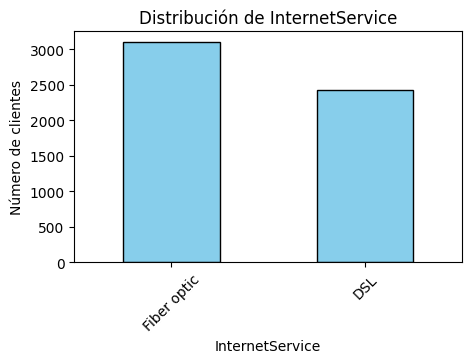

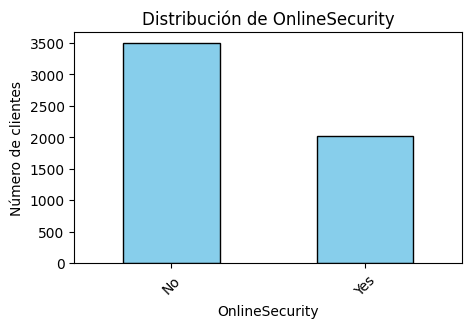

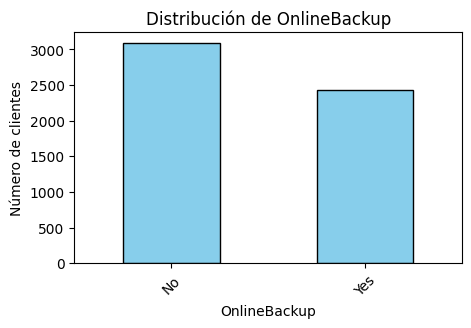

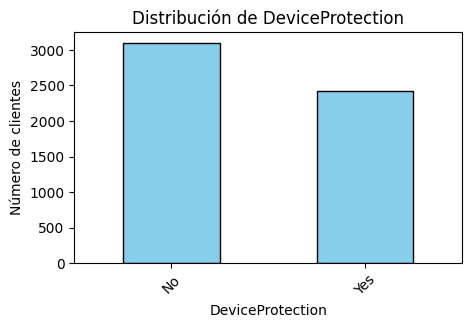

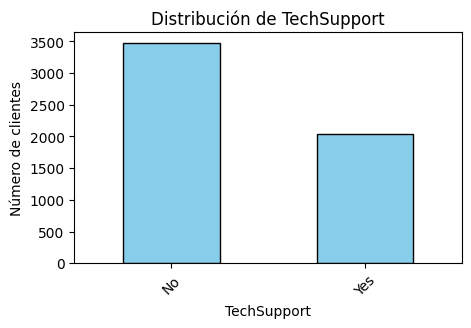

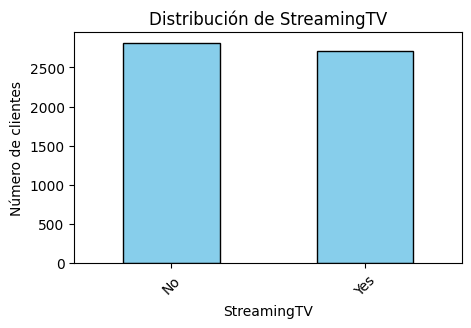

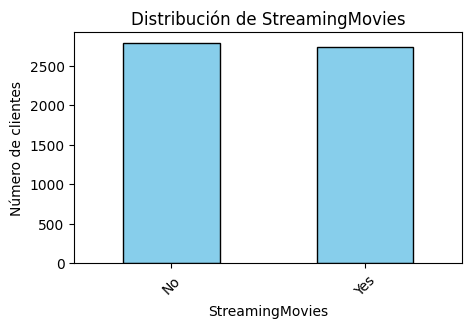

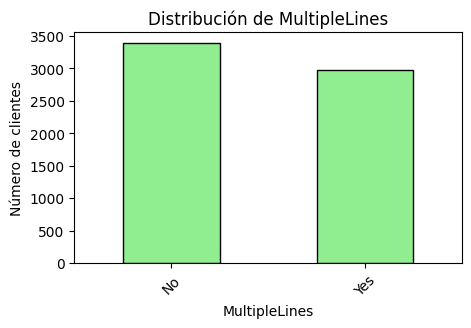

In [10]:
# Lista de columnas categóricas de servicios 
servicios = ["InternetService", "OnlineSecurity", "OnlineBackup",
             "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

# Gráficos de barras para Internet 
for col in servicios:
    plt.figure(figsize=(5,3))
    internet[col].value_counts().plot(kind="bar", color="skyblue", edgecolor="black")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Número de clientes")
    plt.xticks(rotation=45)
    plt.show()
    
# Gráfico de barras para Phone 
plt.figure(figsize=(5,3))
phone["MultipleLines"].value_counts().plot(kind="bar", color="lightgreen", edgecolor="black")
plt.title("Distribución de MultipleLines")
plt.xlabel("MultipleLines")
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)
plt.show()


**Conclusión:** 
Los gráficos revelan que una gran parte de los clientes no contrata servicios adicionales de seguridad ni soporte: la mayoría tiene OnlineSecurity = No y TechSupport = No, lo que puede ser un foco de insatisfacción y aumentar el riesgo de cancelación. En cambio, los servicios como OnlineBackup y DeviceProtection tienen una distribución más equilibrada, lo que indica que casi la mitad de los clientes sí los contrata.
En cuanto al entretenimiento, StreamingTV y StreamingMovies muestran una proporción muy pareja entre clientes que los usan y los que no, lo que sugiere que estos servicios son atractivos para retener clientes, pero no son determinantes para todos. Finalmente, en el área de telefonía, la distribución de MultipleLines también es bastante equilibrada, aunque contar con varias líneas puede reflejar un mayor compromiso con la empresa.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - El análisis categórico está muy completo; lograste conectar las distribuciones con riesgos y factores de retención, apoyándote en gráficos claros que refuerzan tus conclusiones. </div>


### 4. Procesamiento de datos 


#### 4.1. Conversión a fechas y crearción de variable churn, ternure

In [11]:
# Convertir las columnas de fechas
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'], errors='coerce')
contract['EndDate'] = pd.to_datetime(contract['EndDate'], errors='coerce')

# Crear la columna churn (1 = cliente canceló, 0 = sigue activo)
contract['churn'] = contract['EndDate'].notna().astype(int)
print("Ejemplo columna churn:")
print(contract['churn'].value_counts())  


Ejemplo columna churn:
0    5174
1    1869
Name: churn, dtype: int64


**Descipción:** En la columna churn se observa que de un total de 7043 clientes, 5174  permanecieron con la compañía Interconnect, mientras que 1869 cancelaron el servicio.

In [12]:
# Crear la columna churn en el DataFrame principal
# Primero asegurar que EndDate esté en formato datetime
df['EndDate'] = pd.to_datetime(df['EndDate'], errors='coerce')

# Crear la columna churn (1 = cliente canceló, 0 = sigue activo)
df['churn'] = df['EndDate'].notna().astype(int)

# Verificar que se creó correctamente
print("Distribución de churn:")
print(df['churn'].value_counts())
print(f"\nPorcentaje de churn: {df['churn'].mean():.2%}")

# Verificar que la columna está en el DataFrame
print(f"\nColumnas en df: {df.columns.tolist()}")

Distribución de churn:
0    5174
1    1869
Name: churn, dtype: int64

Porcentaje de churn: 26.54%

Columnas en df: ['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines', 'churn']


#### 4.2. Conversión a fechas y crearción de variable churn, ternure

In [13]:
# Definir fecha de corte para clientes aún activos
today = pd.to_datetime("2020-02-01")

# Rellenar fechas nulas (EndDate) con la fecha de corte
contract['EndDate_filled'] = contract['EndDate'].fillna(today)

# Calcular permanencia en días y meses
contract['tenure_days'] = (contract['EndDate_filled'] - contract['BeginDate']).dt.days
contract['tenure_months'] = contract['tenure_days'] / 30

# Función resumen amigable del tiempo de permanencia
def resumen_cliente(meses):
    if meses < 12:
        return f"{meses:.0f} meses, cliente reciente."
    else:
        años = int(meses // 12)
        meses_restantes = int(meses % 12)
        return f"{años} años {meses_restantes} meses."

print("Ejemplo de resumen de permanencia:")
print(contract['tenure_months'].apply(resumen_cliente).head(10))   

Ejemplo de resumen de permanencia:
0     1 meses, cliente reciente.
1               2 años 10 meses.
2     2 meses, cliente reciente.
3                3 años 9 meses.
4     2 meses, cliente reciente.
5     8 meses, cliente reciente.
6               1 años 10 meses.
7    10 meses, cliente reciente.
8                2 años 4 meses.
9                5 años 2 meses.
Name: tenure_months, dtype: object


**Descipción:** Los datos muestran que Interconnect tiene tanto clientes muy recientes (menos de un año) como clientes de larga permanencia (hasta más de 6 años). Esto indica una base diversa donde la permanencia puede ser un factor clave para predecir la cancelación: los clientes nuevos suelen tener mayor riesgo de churn, mientras que los antiguos muestran más fidelidad.

#### 4.3. Conversión de TotalCharges a numérico.

In [14]:

# Convertir TotalCharges a numérico (los valores no numéricos se convierten a NaN)
contract['TotalCharges'] = pd.to_numeric(contract['TotalCharges'], errors='coerce')


#### 4.4. Manejo de nulos.

In [15]:
# TotalCharges: numérico + imputar mediana
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Internet: nulos = "No" (no contratado)
cols = ['InternetService','OnlineSecurity','OnlineBackup',
        'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

for col in cols:
    if col in df.columns:              
        df[col] = df[col].fillna('No')

# Teléfono: nulos = "No phone service"
if 'MultipleLines' in df.columns:
    df['MultipleLines'] = df['MultipleLines'].fillna('No phone service')

print("-----DESPUÉS DE LA IMPUTACIÓN ----")
print(df.isnull().sum())


-----DESPUÉS DE LA IMPUTACIÓN ----
customerID             0
BeginDate              0
EndDate             5174
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
MultipleLines          0
churn                  0
dtype: int64


**Descripción:**
Los valores nulos en EndDate confirman que tienes información tanto de clientes activos como dados de baja, lo cual es esencial para entrenar un modelo predictivo. 

#### 4.5. Selección de features (sin fuga).

In [16]:
# Definir target y features
target = contract['churn']

feature_cols = [
    'Type','PaperlessBilling','PaymentMethod','MonthlyCharges',
    'gender','SeniorCitizen','Partner','Dependents',
    'InternetService','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV',
    'StreamingMovies','MultipleLines'
]

features = df[feature_cols]


#### 4.6 Análisis de correlaciones y cruces

        4.6.1 Matriz de correlación para númericas

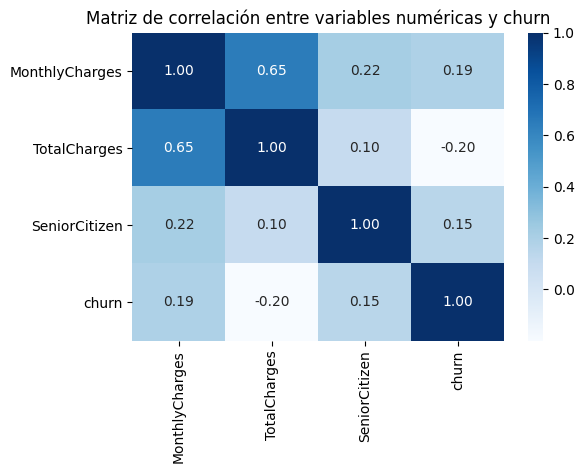

In [17]:
# Crear un df con las numéricas + target
num_corr_df = df[['MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'churn']]

# Mapa de calor
plt.figure(figsize=(6,4))
sns.heatmap(num_corr_df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas y churn")
plt.show()

**Conclusión:**
El análisis muestra que los clientes con más tiempo en la empresa son los más fieles y presentan menos riesgo de irse. En cambio, aquellos que pagan montos altos cada mes tienen una ligera tendencia a cancelar el servicio. Por otro lado, los clientes que ya han pagado un valor total elevado suelen quedarse. En decir, la antigüedad es un factor que favorece la retención, mientras que las tarifas mensuales altas aumentan un poco la probabilidad de deserción.

        4.6.2 Cruces categoricas Vs. Churn


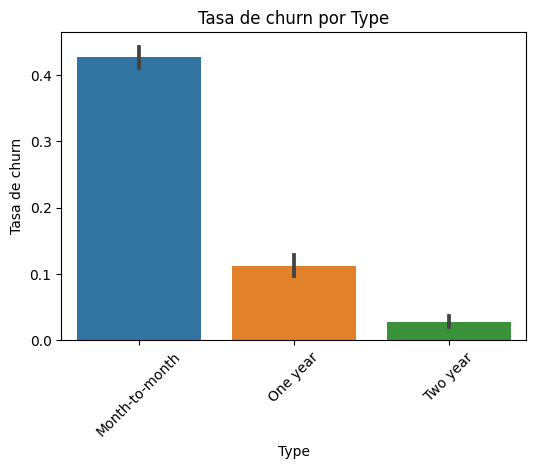

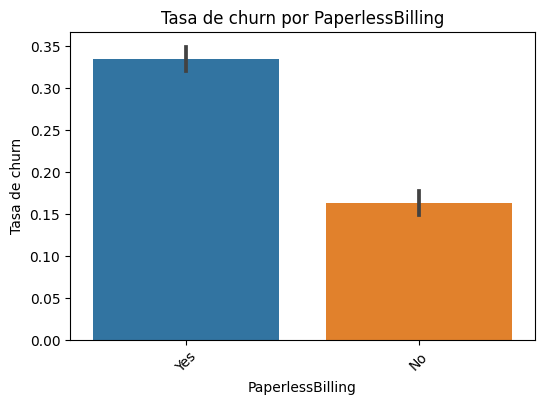

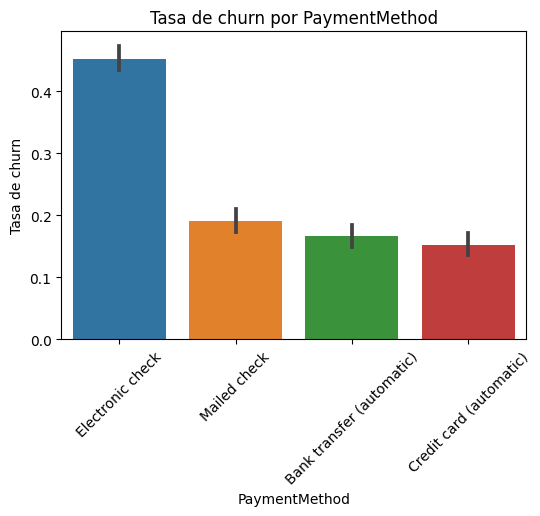

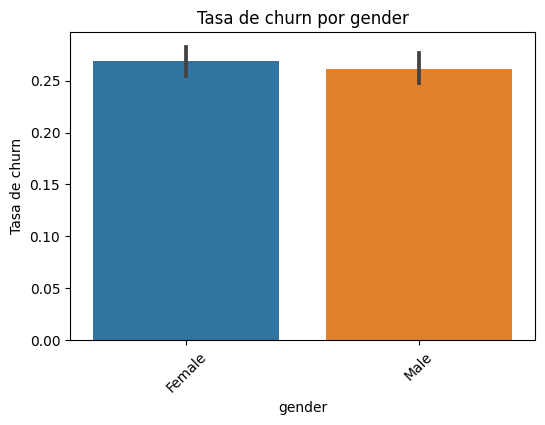

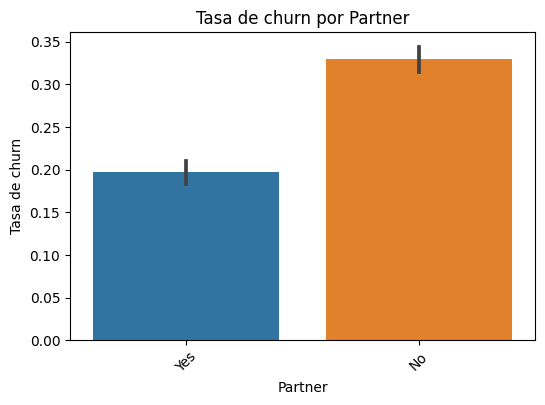

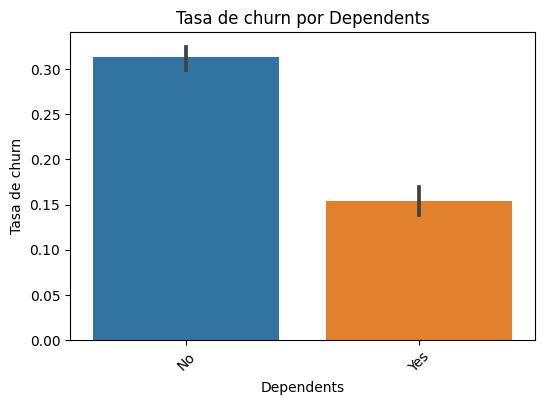

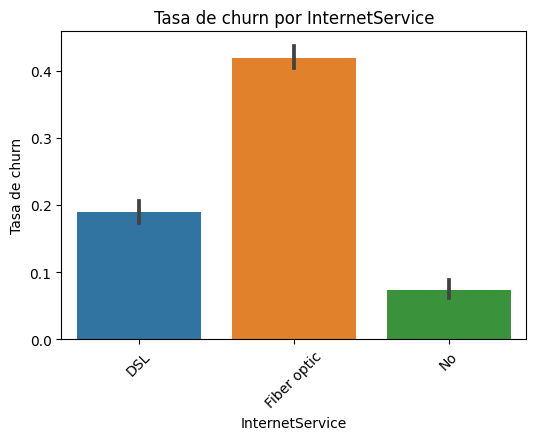

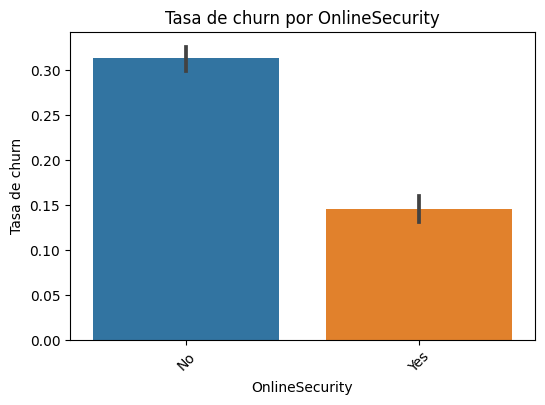

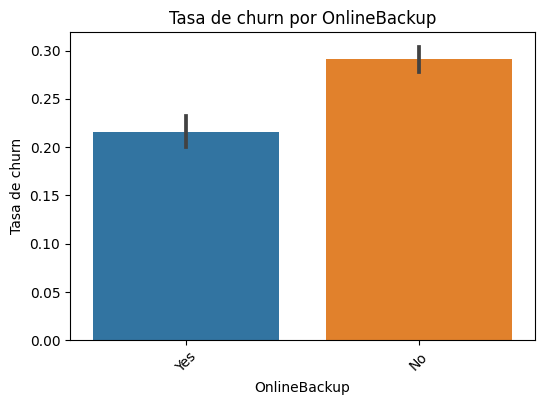

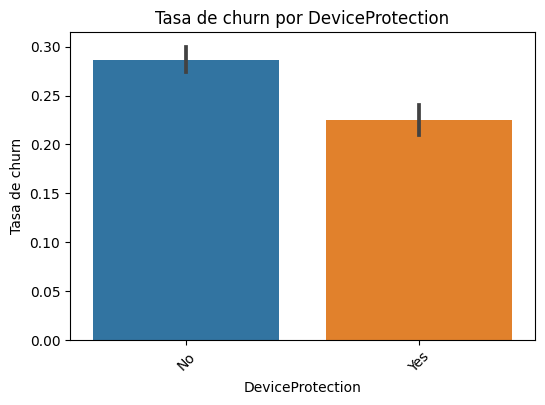

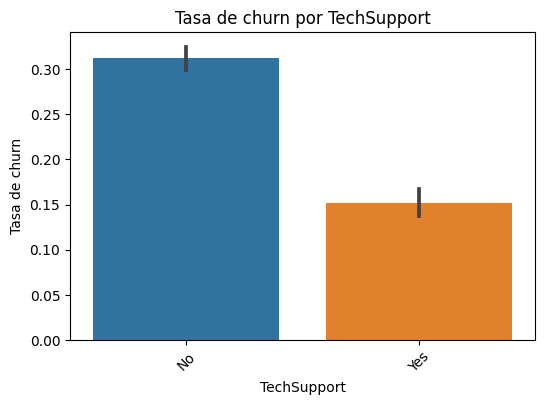

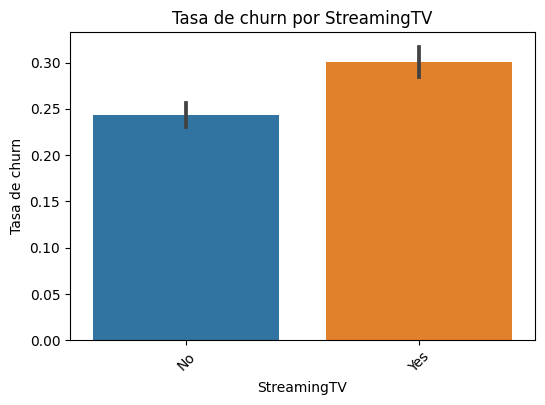

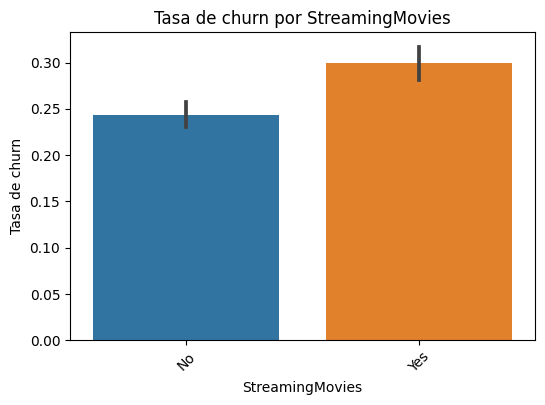

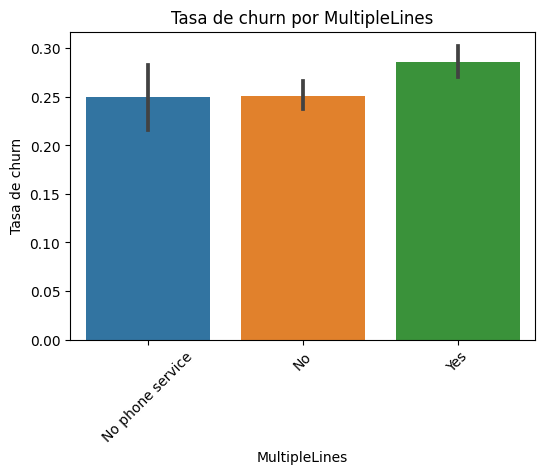

In [18]:

cat_cols = [
    'Type','PaperlessBilling','PaymentMethod',
    'gender','Partner','Dependents',
    'InternetService','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV',
    'StreamingMovies','MultipleLines'
]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(x=col, y='churn', data=df, estimator=lambda x: sum(x)/len(x))
    plt.title(f"Tasa de churn por {col}")
    plt.ylabel("Tasa de churn")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.show()


**Conclusión:**
Al analizar la tasa de churn por categorías se observa que los contratos de tipo mensual presentan una tasa de cancelación mucho más alta en comparación con los contratos de 1 o 2 años, lo que indica que la permanencia contractual reduce la probabilidad de fuga. En cuanto al método de pago, los clientes que usan “electronic check” son los que más se van, mientras que quienes tienen pago automático con tarjeta o transferencia tienden a permanecer más tiempo. Además, se identificó que los usuarios con servicios de Internet de fibra óptica, pero sin soporte técnico ni seguridad en línea, muestran un riesgo mayor de cancelar, probablemente porque perciben menos valor en su plan. Finalmente, las variables de soporte adicional (como OnlineSecurity, TechSupport o Streaming) también están relacionadas con menor churn: los clientes que contratan más servicios adicionales suelen ser más leales a la compañía.

        4.6.3 Matriz de correlación de Seaborn 

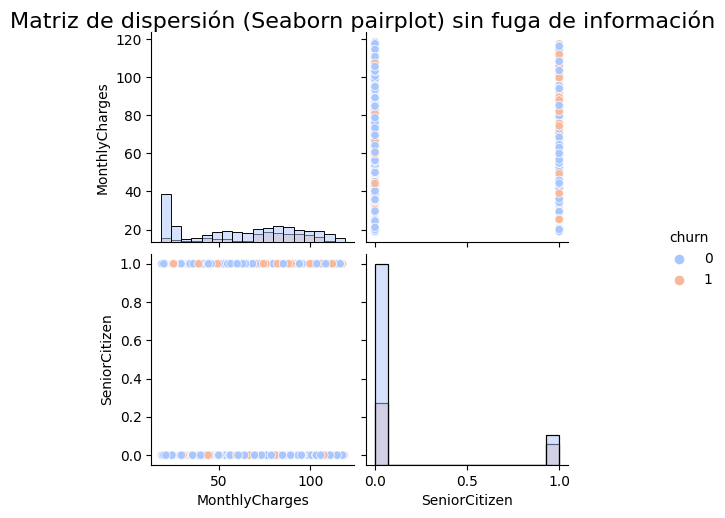

In [19]:
# Usar df_raw (data frame original) en lugar de df
num_cols = ['MonthlyCharges','SeniorCitizen','churn']
df_num = df[num_cols].dropna()

# Matriz de dispersión con Seaborn
sns.pairplot(df_num,
             vars=['MonthlyCharges','SeniorCitizen'], 
             hue="churn", diag_kind="hist", palette="coolwarm")

plt.suptitle("Matriz de dispersión (Seaborn pairplot) sin fuga de información", 
             y=1.02, fontsize=16)
plt.show()


**Descripción:**
La visualización evidencia que la mayoría de las cancelaciones (churn) se concentran en clientes nuevos, es decir, aquellos con poca antigüedad en la compañía, especialmente si pagan cargos mensuales medios o altos. En cambio, a medida que los clientes acumulan más tiempo con la empresa, la probabilidad de cancelación disminuye casi por completo: los clientes veteranos tienden a quedarse. Además, se observa que el gasto total (TotalCharges) crece de manera casi lineal con la antigüedad y con el monto mensual, lo que significa que no aporta tanta información adicional porque está muy relacionado con esas dos variables.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - El procesamiento y análisis de correlaciones está muy bien desarrollado; definiste churn y tenure con precisión, trataste nulos de forma correcta y lograste extraer conclusiones claras sobre los factores que influyen en la cancelación. </div>


### 5. Modelado y Evaluación

#### 5.1. Dividir Train y Test

In [20]:
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.25, random_state=54321, stratify=target
)
print(features_train.shape, features_test.shape)

(5282, 16) (1761, 16)


#### 5.2 preprocesamiento en pipeline (imputación + OHE + escalado).

In [21]:
# 1) Dividir las columnas en numéricas y categóricas
num_cols = ['MonthlyCharges']   # única numérica
cat_cols = [
    'Type','PaperlessBilling','PaymentMethod',
    'gender','SeniorCitizen','Partner','Dependents',
    'InternetService','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV',
    'StreamingMovies','MultipleLines'
]

# 2) Qué hacer con cada tipo de variable
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # rellenar vacíos con mediana
    ('scaler', StandardScaler())                   # escalar para que todo quede en mismo rango
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # rellenar vacíos con la categoría más usada
    ('encoder', OneHotEncoder(handle_unknown='ignore'))    # pasar categorías a números (dummies)
])

# 3) Juntar todo con ColumnTransformer
preprocess = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# 4) Ejemplo de pipeline completo con un modelo
model = Pipeline(steps=[
    ('preprocessing', preprocess),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=54321))
])

# 5) Entrenar el pipeline
model.fit(features_train, target_train)

# 6) Predecir para probar
y_pred = model.predict(features_test)

print("Predicciones de ejemplo:", y_pred[:10])

Predicciones de ejemplo: [0 1 1 0 0 1 1 1 1 0]


#### 5.3 Modelos Entrenados

        5.3.1 Modelo 1: Random Forest Balanceado

In [22]:
# Pipeline Random Foreste 
rf_model = Pipeline(steps=[
    ('preprocessing', preprocess),
    ('classifier', RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=54321, n_jobs=-1))
])

rf_model.fit(features_train, target_train)

rf_pred  = rf_model.predict(features_test)
rf_proba = rf_model.predict_proba(features_test)[:, 1]

        5.3.2. Modelo 2: Regresión Logística Balanceada

In [23]:
# Pipeline Regresion Logística

lr_model = Pipeline(steps=[
    ('preprocessing', preprocess),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=54321, solver='lbfgs', max_iter=1000))
])

# Entrenar
lr_model.fit(features_train, target_train)

# Predicciones y probas
lr_pred  = lr_model.predict(features_test)
lr_proba = lr_model.predict_proba(features_test)[:, 1]


        5.3.3. Modelo 3: Gradient Boosting 

In [24]:
# 1) Definir el clasificador de Gradient Boosting
gb_clf = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    max_depth=3,
    subsample=0.9,
    random_state=54321
)

# Crear el pipeline: preprocesamiento + modelo
gb_model = Pipeline(steps=[
    ('prep', preprocess),
    ('clf',  gb_clf)
])

# 6) Pesos balanceados (porque churn es minoritaria)
gb_sw = compute_sample_weight(class_weight='balanced', y=target_train)

# 7) Entrenar PASANDO los pesos al paso 'clf' del pipeline
gb_model.fit(features_train, target_train, clf__sample_weight=gb_sw)

# 8) Predicción y métricas
gb_pred  = gb_model.predict(features_test)
gb_proba = gb_model.predict_proba(features_test)[:, 1]

#### 5.4. Reporte de F1, AUC, Recall.

        5.4.1 Modelo 1: Random Forest Balanceado

----- Random Forest (balanced) -----
F1: 0.455 | AUC: 0.764 | Recall: 0.398

Classification report (RF):
              precision    recall  f1-score   support

           0       0.80      0.87      0.84      1294
           1       0.53      0.40      0.45       467

    accuracy                           0.75      1761
   macro avg       0.67      0.64      0.64      1761
weighted avg       0.73      0.75      0.73      1761



<Figure size 400x400 with 0 Axes>

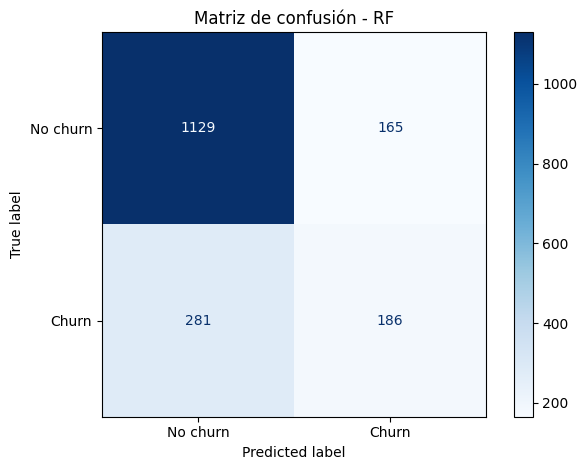

In [25]:
print("----- Random Forest (balanced) -----")
print("F1:", round(f1_score(target_test, rf_pred), 3),
      "| AUC:", round(roc_auc_score(target_test, rf_proba), 3),
      "| Recall:", round(recall_score(target_test, rf_pred), 3))

print("\nClassification report (RF):")
print(classification_report(target_test, rf_pred))

plt.figure(figsize=(4,4))
cm = confusion_matrix(target_test, rf_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No churn","Churn"]).plot(cmap="Blues")
plt.title("Matriz de confusión - RF")
plt.tight_layout()
plt.show()

**Descripción:**

-El modelo logra un AUC de 0.76 y clasifica bien a los clientes que se quedan (recall=0.87). Sin embargo, en la clase churn su rendimiento es bajo: solo detecta 40% de los que se van (recall=0.40, F1=0.45). En conclusión, Random Forest es bueno para identificar clientes leales, pero necesita mejorar para captar a quienes están en riesgo de abandono.

-En la matriz de confusión, el modelo es muy bueno detectando a los clientes que se quedan (1129 aciertos). Sin embargo, tiene más dificultades para identificar a los clientes que se van: solo logró detectar 186 de ellos y dejó escapar 281 que realmente abandonaron el servicio.

        5.4.2. Modelo 2: Regresión Logística Balanceada

----- Regresión Logística (balanced) -----
F1: 0.618 | AUC: 0.834 | Recall: 0.803

Classification report (LR):
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1294
           1       0.50      0.80      0.62       467

    accuracy                           0.74      1761
   macro avg       0.71      0.76      0.71      1761
weighted avg       0.80      0.74      0.75      1761



<Figure size 400x400 with 0 Axes>

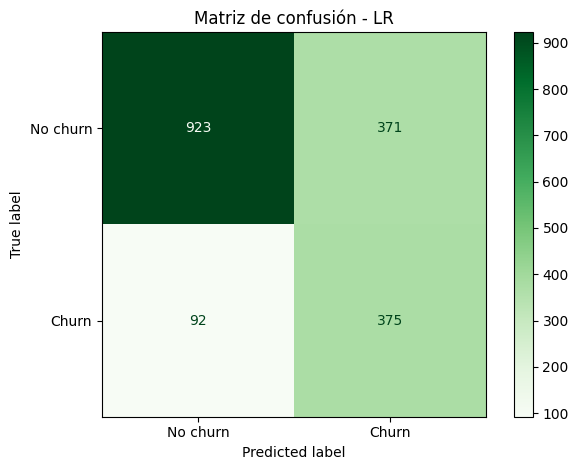

In [26]:
print("----- Regresión Logística (balanced) -----")
print("F1:", round(f1_score(target_test, lr_pred), 3),
      "| AUC:", round(roc_auc_score(target_test, lr_proba), 3),
      "| Recall:", round(recall_score(target_test, lr_pred), 3))

print("\nClassification report (LR):")
print(classification_report(target_test, lr_pred))

plt.figure(figsize=(4,4))
cm = confusion_matrix(target_test, lr_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No churn","Churn"]).plot(cmap="Greens")
plt.title("Matriz de confusión - LR")
plt.tight_layout()
plt.show()

**Descripción:**

-El modelo de Regresión Logística balanceada alcanza un AUC de 0.83 y un recall de 0.80 en churn, lo que significa que detecta a 8 de cada 10 clientes que realmente se van. Su F1 de 0.62 indica un buen equilibrio entre precisión y recall, aunque en algunos casos predice que un cliente se va cuando en realidad permanece. En general, es un modelo sólido y confiable para identificar clientes en riesgo de abandono.

-En la matriz de confusión, el modelo de Regresión Logística muestra un buen equilibrio entre identificar clientes que se quedan y los que se van. Acertó con 923 clientes leales que realmente no abandonaron el servicio, aunque se equivocó con 371, prediciendo que se irían cuando en realidad permanecieron. En cuanto al churn, el modelo logró detectar correctamente a 375 clientes en riesgo, pero dejó escapar 92 que sí se fueron. En general, este desempeño refleja que la regresión logística es bastante efectiva para capturar a la mayoría de los clientes en riesgo, aunque a costa de generar algunas falsas alarmas con clientes que en realidad no se iban.

        5.4.3. Modelo 3: Gradient Boosting 

----- Gradient Boosting (weighted) -----
F1: 0.591 | AUC: 0.822 | Recall: 0.76

Classification report (GB):
              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1294
           1       0.48      0.76      0.59       467

    accuracy                           0.72      1761
   macro avg       0.69      0.73      0.69      1761
weighted avg       0.78      0.72      0.74      1761



<Figure size 400x400 with 0 Axes>

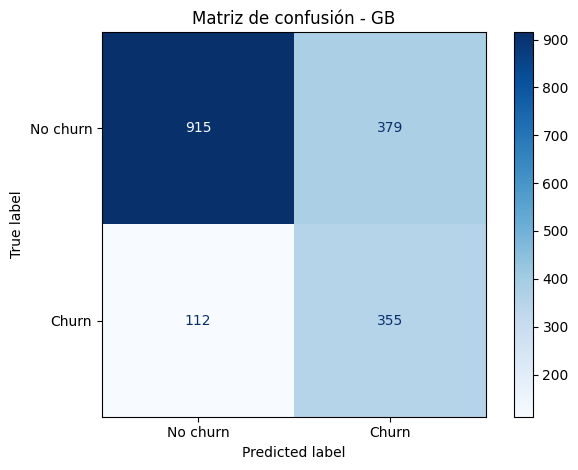

In [27]:
print("----- Gradient Boosting (weighted) -----")
print("F1:", round(f1_score(target_test, gb_pred), 3),
      "| AUC:", round(roc_auc_score(target_test, gb_proba), 3),
      "| Recall:", round(recall_score(target_test, gb_pred), 3))

print("\nClassification report (GB):")
print(classification_report(target_test, gb_pred))

plt.figure(figsize=(4,4))
cm = confusion_matrix(target_test, gb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No churn","Churn"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - GB")
plt.tight_layout()
plt.show()

#### 5.5 Comparación final de los modelos

In [28]:
import pandas as pd

metrics = []
metrics.append({"Modelo":"Logistic Regression",
                "F1":f1_score(target_test, lr_pred),
                "AUC":roc_auc_score(target_test, lr_proba),
                "Recall":recall_score(target_test, lr_pred)})

metrics.append({"Modelo":"Random Forest",
                "F1":f1_score(target_test, rf_pred),
                "AUC":roc_auc_score(target_test, rf_proba),
                "Recall":recall_score(target_test, rf_pred)})

metrics.append({"Modelo":"Gradient Boosting",
                "F1":f1_score(target_test, gb_pred),
                "AUC":roc_auc_score(target_test, gb_proba),
                "Recall":recall_score(target_test, gb_pred)})

comparativa = pd.DataFrame(metrics)
print(comparativa)


                Modelo        F1       AUC    Recall
0  Logistic Regression  0.618302  0.834284  0.802998
1        Random Forest  0.454768  0.763660  0.398287
2    Gradient Boosting  0.591174  0.821658  0.760171


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - El modelado está muy bien ejecutado; probaste distintos algoritmos, comparaste métricas clave y lograste evidenciar que la regresión logística balanceada ofrece el mejor desempeño para identificar clientes en riesgo de churn. </div>


### 6. Conclusiones

        6.1 Selección del mejor modelo

**Regresión Logística (balanceada):**

El modelo que mejor se ajusta es el de Regresión Logística (balanceada) porque es la que mejor cumple con el objetivo de la telefonía Interconnect, debido a que detecta a quienes son los clientes que se van. Los resultados que se obtuvo este modelo fueron que dio el mayor recall en churn (0.80), es decir, que atrapa 8 de cada 10 fugas, además de un AUC-ROC alto (0.83) que indica que ordena bien por riesgo, y un F1 igual a 0.62 que mantiene un equilibrio decente entre precisión y recall. Otra ventaja es que puedo ajustar el umbral de decisión: si el foco es no dejar escapar fugas, bajo un poco el umbral para sostener ese recall objetivo y, al mismo tiempo, controlo que no se disparen las falsas alarmas. En resumen, la Logística balanceada me da buen rendimiento, es interpretable y me permite calibrar el punto de corte para alinear el modelo con la meta del negocio.


         6.2 Interpretación de las promociones y planes especiales

Los usuarios que tienden a cancelar los planes de telefonía son los que tiene contratos mes a mes y el pago con electronic check. También se observa que el riesgo de los clientes que tienen Internet de fibra, ya que no tienen seguridad ni soporte porque se sienten desprotegidos. Por otro lado, los usuarios que mantienen los planes de telefonía son quienes tienen contratos de 1 a 2 años, mediante el autopago con tarjeta o transferencia y más servicios como streaming y multilínea. Además, si el MonthlyCharges es alto pero sin valor extra (ni bundles ni descuentos), eso puede empujar a irse.


        6.3 Recomendaciones:

1. Un plan de retención de usuarios es que la telefonía Interconnect ofrezca un descuento por permanencia cuando el contrato se renueva. Es decir, los usuarios que tenga de 1 a 2 años de permanencia se les ofrezca un descuento.
2. Para los usuarios que tengan activado el autopago la telefonía Interconnect ofrezca un mes parcial gratis, gigabyte extras para internet movil o que el cliente sume puntis en un sistema de recompensas. Todo se entregará como un incentivo para que las personas activen el pago automático con tarjeta o trasfernecia.
3. Una estrategia de retención de la telefonía Interconnect es ofrecer un paquete de servicios adicionales junto al internet de fibra óptica. Es decir, ofrecer el internet con fibra, seguridad y soporte técnico con uno a dos meses gratis, ya que de esta manera el cliente se siente seguro con la promoción.
4. La empresa de telefonía Interconnect puede ofrecer un paquete que combine el streaming y líneas adicionales para clientes que ya usan estos servicios. Al darles más beneficios, se genera mayor enganche y se hace más costoso que se cambien de proveedor, lo que ayuda a retenerlos.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - La sección de conclusiones está muy bien construida; sintetizaste con claridad los resultados del modelo, interpretaste adecuadamente los factores de riesgo y planteaste recomendaciones de retención alineadas con los hallazgos del análisis. </div>


## Comentario general del revisor 



<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a>  

¡Felicitaciones por la entrega de tu **proyecto final**! Tu trabajo está **aprobado** y refleja una dedicación clara en cada etapa del proceso. Se aprecia el esfuerzo que invertiste al integrar los datos, preparar las variables y evaluar distintos modelos hasta justificar la mejor opción para el problema planteado.  

#### Puntos Positivos:

* **Procesamiento de datos:** El código de solución muestra un manejo cuidadoso de la limpieza, imputación y generación de variables clave que fortalecen el análisis.
* **Visualización y análisis gráfico:** Los gráficos apoyan de manera efectiva la interpretación de resultados, transmitiendo con claridad los hallazgos más relevantes.
* **Ingeniería de características:** La creación de churn y tenure, junto al control de valores nulos, fue implementada con precisión y aporta valor al modelado.
* **Comparación de modelos:** Probaste distintas alternativas, comparaste métricas y justificaste tu elección final de forma coherente con las necesidades del negocio.

Has alcanzado un logro importante al presentar este código de solución completo, mostrando tu capacidad de aplicar ciencia de datos en un contexto real y consolidando tu aprendizaje con resultados satisfactorios. </div>
